# 10 — Difference-in-Differences & Event Study
**Autores clave:** Baker, Callaway, Cunningham, Goodman-Bacon & Sant'Anna (2026) *"DiD Designs: A Practitioner's Guide"* (*JEL* 64(2)) · Card & Krueger (1994) · Angrist & Pischke (2009) Cap. 5 · Bertrand, Duflo & Mullainathan (2004) · Sant'Anna & Zhao (2020) · Callaway & Sant'Anna (2021) · Goodman-Bacon (2021) · Roth et al. (2023) · Rambachan & Roth (2023) · Mixtape Sessions: *Advanced DiD* (Roth) y *Frontiers in DiD* (Callaway)

## 1. El problema de identificación causal

DiD resuelve el problema fundamental de la inferencia causal cuando la asignación al tratamiento **no es aleatoria** pero sigue un patrón predecible en el tiempo. La clave es usar la variación temporal junto con un grupo de comparación.

### Supuesto de Tendencias Paralelas (Parallel Trends)

> "In the absence of treatment, the average outcomes for the treated and control groups would have followed parallel paths over time." — Angrist & Pischke (2009, p. 228)

Formalmente: $E[Y_{it}(0) - Y_{it'}(0) \mid D_i = 1] = E[Y_{it}(0) - Y_{it'}(0) \mid D_i = 0]$ para $t > t' < T^*$

Este supuesto es **no testeable** en el período post-tratamiento, pero se puede evaluar con datos pre-tratamiento (event study).

## 2. Estimador DiD: tres representaciones equivalentes

**Representación 1 — Diferencias de medias:**
$$\hat{\tau}^{DiD} = \underbrace{(\bar{Y}_{T,\text{post}} - \bar{Y}_{T,\text{pre}})}_{\text{cambio tratados}} - \underbrace{(\bar{Y}_{C,\text{post}} - \bar{Y}_{C,\text{pre}})}_{\text{cambio controles}}$$

**Representación 2 — OLS con interacción:**
$$Y_{it} = \alpha + \beta_1 \text{Treated}_i + \beta_2 \text{Post}_t + \delta (\text{Treated}_i \times \text{Post}_t) + \varepsilon_{it}$$
$\delta$ = estimador DiD. Bajo OLS, $\hat{\delta} = \hat{\tau}^{DiD}$ exactamente.

**Representación 3 — TWFE (Two-Way Fixed Effects):**
$$Y_{it} = \alpha_i + \lambda_t + \delta (\text{Treated}_i \times \text{Post}_t) + \varepsilon_{it}$$
Los efectos fijos $\alpha_i$ y $\lambda_t$ absorben toda la heterogeneidad constante de unidad y todo shock temporal común, haciendo innecesario incluir `Treated` y `Post` separadamente.

> **Equivalencia:** Con dos grupos y dos períodos, las tres representaciones dan exactamente el mismo $\hat{\delta}$. Con más períodos o grupos, TWFE es la versión generalizada.

## 3. Event Study: efectos dinámicos

$$Y_{it} = \alpha_i + \lambda_t + \sum_{k \neq -1} \delta_k \cdot \mathbf{1}[\text{Treated}_i] \cdot \mathbf{1}[t - T_i^* = k] + \varepsilon_{it}$$

- $k < 0$: coeficientes **pre-tratamiento** → deben ser ≈ 0 si las tendencias son paralelas
- $k \geq 0$: coeficientes **post-tratamiento** → perfil dinámico del efecto
- $k = -1$: período de referencia (omitido para evitar multicolinealidad perfecta)

**Ventajas sobre el DiD estático:**
1. Detecta violaciones de tendencias paralelas (pre-trends)
2. Revela si el efecto es inmediato o se acumula gradualmente (Ashenfelter's dip)
3. Testea si el efecto persiste en el tiempo o se desvanece

## 4. Problema del TWFE con Staggered Adoption (Goodman-Bacon, 2021)

Con timing de tratamiento variable ($T_i^* \neq T_j^*$), el estimador TWFE es:
$$\hat{\delta}_{TWFE} = \sum_{k,l} \hat{w}_{kl} \cdot \hat{\Delta}^{DiD}_{kl}$$

donde la suma corre sobre **todos los pares 2×2** (grupos $k$ y $l$, tratados en $T_k^*$ y $T_l^*$). Los pesos $\hat{w}_{kl}$ pueden ser **negativos** cuando:
- Unidades ya tratadas actúan como "control" para unidades que se tratan después
- El efecto del tratamiento varía en el tiempo (no es constante)

> **Goodman-Bacon (2021, Proposición 1):** $\hat{\delta}_{TWFE} = \sum_{g \neq g'} s_{gg'} \cdot \hat{\delta}_{gg'}$ donde $s_{gg'}$ puede ser negativo cuando los grupos "ya tratados" sirven de comparación.

## 5. Solución: ATT(g,t) — Callaway & Sant'Anna (2021)

En lugar de un único $\hat{\delta}$, estimar efectos **por cohorte y período**:
$$ATT(g,t) = E[Y_t(g) - Y_t(0) \mid G = g] \quad \text{para } t \geq g$$

donde $G = g$ indica que la unidad fue tratada por primera vez en el período $g$.

Luego agregar con pesos económicamente relevantes:
$$\theta^{simple} = \sum_{g} \sum_{t \geq g} w(g,t) \cdot ATT(g,t)$$

Esta estrategia es **robusta a heterogeneidad de efectos** porque nunca usa unidades "ya tratadas" como control para otras.
## 6. El marco de "forward engineering" (Baker et al., 2026)

La guía del practicante del *JEL* organiza todo diseño DiD moderno en tres pasos:

```
1. Definir el PARÁMETRO OBJETIVO   (¿qué ATT? ¿ponderado por unidades o por población?)
2. Declarar los SUPUESTOS          (¿qué versión de tendencias paralelas? ¿no anticipación? ¿overlap?)
3. Derivar el ESTIMADOR de 1 + 2   <- "forward engineering"
```

y no al revés ("reverse engineering": correr la regresión familiar y preguntarse después
qué estima). Todo diseño complejo es una **agregación de bloques 2×2**, cada uno válido
bajo su propio supuesto explícito. Los supuestos llevan nombre:

| Supuesto | Enunciado |
|---|---|
| **NA** (No Anticipación) | $Y_{it}(1) = Y_{it}(0)$ en todos los períodos pre-tratamiento |
| **PT** (2×2) | $E[\Delta Y(0) \mid D{=}1] = E[\Delta Y(0) \mid D{=}0]$ |
| **CPT** (condicional) | PT vale *dentro* de cada estrato de covariables $X$ |
| **SO** (overlap fuerte) | $\epsilon < P(D{=}1 \mid X) < 1-\epsilon$ |
| **PT-GT-NEV / NYT / ALL** | PT por cohorte usando nunca-tratados / aún-no-tratados / todos |

Dos lecciones prácticas del ejemplo Medicaid del paper: (i) **los pesos definen el
parámetro** — el 2×2 sin ponderar dio $+0.1$ muertes por 100k y el ponderado por población
$-2.6$: no es un chequeo de robustez, son dos parámetros distintos; (ii) PT es **sensible a
la forma funcional** (niveles vs logs son supuestos diferentes; test de falsación en
Roth & Sant'Anna 2023b).


## Notación

### Índices y conjuntos

| Símbolo | Definición |
|---|---|
| $i = 1, \ldots, N$ | Índice de unidad (individuo, firma, estado) |
| $t = 1, \ldots, T$ | Índice de período |
| $T^*$ | Período de inicio del tratamiento |
| $k = t - T^*$ | **Tiempo relativo** al tratamiento: $k < 0$ = pre, $k \geq 0$ = post |
| $\mathcal{T}$ | Conjunto de unidades tratadas |
| $\mathcal{C}$ | Conjunto de unidades de control |
| $G = g$ | Cohorte: unidades tratadas por primera vez en el período $g$ |

### Variables

| Símbolo | Definición |
|---|---|
| $Y_{it}$ | Outcome observado de la unidad $i$ en período $t$ |
| $Y_{it}(1)$ | Outcome potencial **con** tratamiento (Rubin, 1974) |
| $Y_{it}(0)$ | Outcome potencial **sin** tratamiento (contrafactual) |
| $D_i \in \{0,1\}$ | Indicador de pertenencia al grupo tratado (fijo en el tiempo) |
| $D_{it} \in \{0,1\}$ | Indicador de tratamiento activo en $(i,t)$ — puede variar |
| $\text{Post}_t = \mathbf{1}[t \geq T^*]$ | Dummy de período post-tratamiento |

### Efectos causales

| Símbolo | Definición |
|---|---|
| $\tau_i = Y_{it}(1) - Y_{it}(0)$ | Efecto de tratamiento individual (nunca observable) |
| $ATE = E[\tau_i]$ | Average Treatment Effect — promedio sobre toda la población |
| $ATT = E[\tau_i \mid D_i = 1]$ | Average Treatment Effect on the Treated |
| $\delta$ | Estimador DiD (identifica el ATT bajo tendencias paralelas) |
| $\delta_k$ | Coeficiente del event study en tiempo relativo $k$ |
| $ATT(g,t)$ | ATT de la cohorte $g$ en el período $t$ — Callaway & Sant'Anna (2021) |

### Efectos fijos y errores

| Símbolo | Definición |
|---|---|
| $\alpha_i$ | Efecto fijo de unidad — absorbe heterogeneidad constante en el tiempo |
| $\lambda_t$ | Efecto fijo de período — absorbe shocks temporales comunes |
| $\varepsilon_{it}$ | Error idiosincrático, $E[\varepsilon_{it} \mid \alpha_i, \lambda_t, D_{it}] = 0$ |
| $\tilde{Y}_{it} = Y_{it} - \bar{Y}_i - \bar{Y}_t + \bar{\bar{Y}}$ | Variable demeaned (within transformation) |

### Operadores y notación auxiliar

| Símbolo | Definición |
|---|---|
| $\bar{Y}_{T,\text{pre}}$ | Media del outcome para tratados en el período pre |
| $\bar{Y}_{C,\text{post}}$ | Media del outcome para controles en el período post |
| $\mathbf{1}[\cdot]$ | Función indicadora |
| $\hat{\cdot}$ | Estimador muestral del parámetro poblacional |
| $V_{cluster}$ | Varianza cluster-robust (Liang & Zeger, 1986) |
| $p\text{-value}_{F}$ | P-valor del test F conjunto sobre pre-dummies (test de tendencias paralelas) |

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family': 'Optima'
})
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# Contexto: efecto de política de salario mínimo estatal (Card & Krueger, 1994)
# Estado A sube salario mínimo en t=0. Estado B = control.
# ─────────────────────────────────────────────────────────────────────────────
N_units  = 200   # restaurantes por estado
T_pre    = 8     # períodos pre (k = -8,...,-1)
T_post   = 6     # períodos post (k = 0,...,5)
T        = T_pre + T_post
TRUE_ATT = 3.0   # efecto verdadero

# Efectos fijos de unidad (heterogeneidad no observada)
unit_fe_T = np.random.normal(32, 4, N_units)
unit_fe_C = np.random.normal(30, 4, N_units)

rows = []
for t_idx in range(T):
    k = t_idx - T_pre   # tiempo relativo: -8,...,5
    is_post = int(k >= 0)
    common_trend = 0.3 * t_idx

    for i in range(N_units):
        # Tratados
        y_T = unit_fe_T[i] + common_trend + TRUE_ATT * is_post + np.random.normal(0, 2)
        rows.append({'unit': i, 'state': 'treated', 'treated': 1,
                     't_idx': t_idx, 'k': k, 'post': is_post, 'Y': y_T})
        # Controles
        y_C = unit_fe_C[i] + common_trend + np.random.normal(0, 2)
        rows.append({'unit': N_units + i, 'state': 'control', 'treated': 0,
                     't_idx': t_idx, 'k': k, 'post': is_post, 'Y': y_C})

df = pd.DataFrame(rows)
df['did_term'] = df['treated'] * df['post']

print(f'Panel: {2*N_units} unidades × {T} períodos = {len(df):,} obs')
print(f'Tiempo relativo: k ∈ [{-T_pre}, {T_post-1}]  |  Tratamiento en k=0')
print(f'ATT verdadero: {TRUE_ATT}')

Panel: 400 unidades × 14 períodos = 5,600 obs
Tiempo relativo: k ∈ [-8, 5]  |  Tratamiento en k=0
ATT verdadero: 3.0


## Sección 1 — Gráfica canónica DiD y el estimador 2×2

### ¿Qué identifica el DiD?

El DiD estima el **ATT (Average Treatment Effect on the Treated)**:
$$ATT = E[Y_{it}(1) - Y_{it}(0) \mid D_i = 1, t \geq T^*]$$

A diferencia del ATE (promedio sobre todos), el ATT es el efecto **para las unidades que realmente recibieron el tratamiento** — el parámetro más relevante para evaluación de políticas.

### El contrafactual no observable

El problema fundamental: $Y_{it}(0)$ no es observable para las unidades tratadas en el período post. Necesitamos construirlo:
$$\hat{Y}_{T,\text{post}}^{(0)} = \bar{Y}_{T,\text{pre}} + \underbrace{(\bar{Y}_{C,\text{post}} - \bar{Y}_{C,\text{pre}})}_{\text{tendencia común estimada por controles}}$$

Esto es válido **si y solo si** los controles siguen la misma tendencia que los tratados habrían seguido en ausencia del tratamiento (Parallel Trends).

### Tres representaciones del mismo estimador

| Representación | Ecuación | Cuándo usar |
|---|---|---|
| **2×2 algebraico** | $(\bar{Y}_{T,\text{post}} - \bar{Y}_{T,\text{pre}}) - (\bar{Y}_{C,\text{post}} - \bar{Y}_{C,\text{pre}})$ | Dos grupos, dos períodos |
| **OLS con interacción** | $Y = \alpha + \beta_1 T_i + \beta_2 P_t + \delta(T_i \times P_t) + \varepsilon$ | Permite agregar controles fácilmente |
| **TWFE** | $Y_{it} = \alpha_i + \lambda_t + \delta D_{it} + \varepsilon_{it}$ | Múltiples períodos y grupos |

Las tres son algebraicamente equivalentes en el caso 2×2.

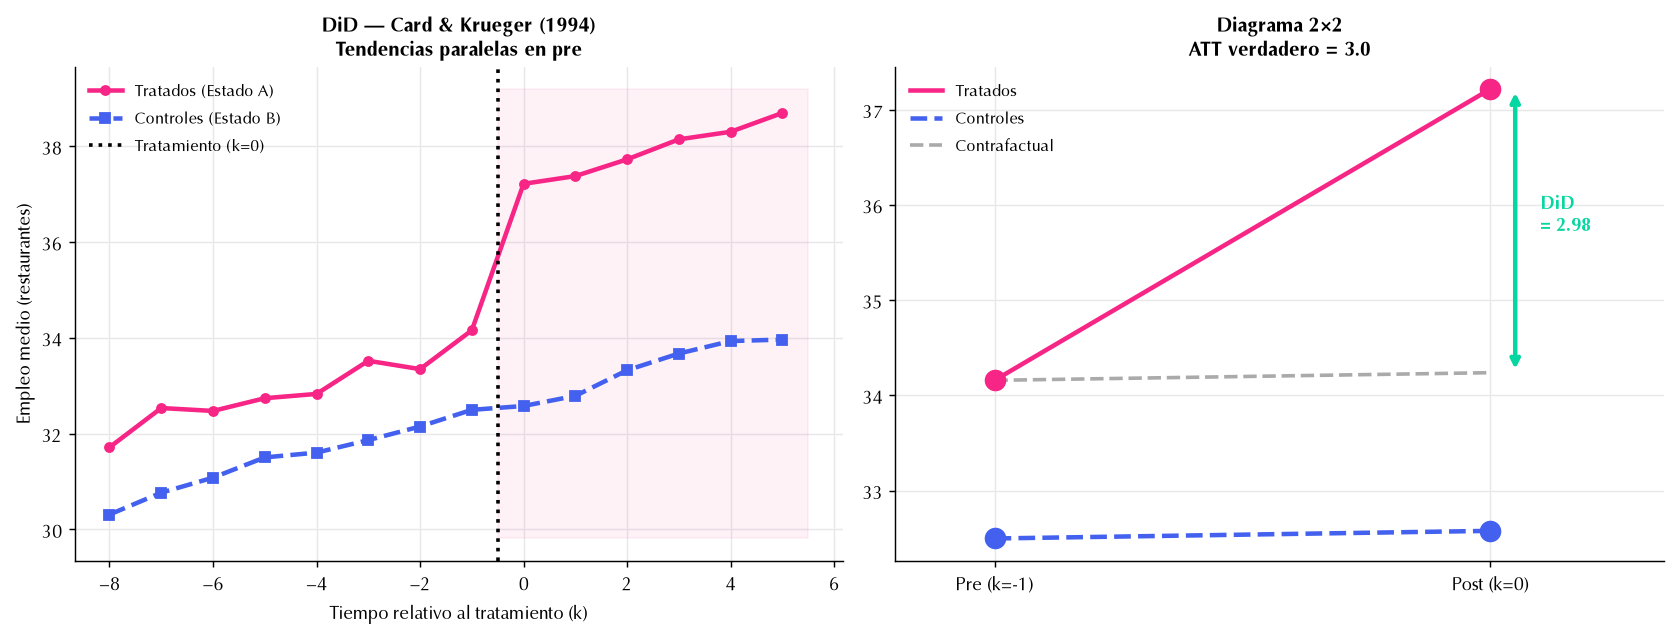

DiD 2×2 estimado: 2.9785  |  ATT verdadero: 3.0


In [9]:
means = df.groupby(['k', 'state'])['Y'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: tendencias completas
ax = axes[0]
ax.plot(means.index, means['treated'], 'o-', color='#f72585', linewidth=2.5,
        markersize=5, label='Tratados (Estado A)')
ax.plot(means.index, means['control'], 's--', color='#4361ee', linewidth=2.5,
        markersize=5, label='Controles (Estado B)')
ax.axvline(-0.5, color='black', linestyle=':', linewidth=2, label='Tratamiento (k=0)')
ax.fill_betweenx([means.values.min()-0.5, means.values.max()+0.5],
                 -0.5, T_post - 0.5, alpha=0.06, color='#f72585')
ax.set_xlabel('Tiempo relativo al tratamiento (k)')
ax.set_ylabel('Empleo medio (restaurantes)')
ax.set_title('DiD — Card & Krueger (1994)\nTendencias paralelas en pre')
ax.legend(fontsize=9)

# Panel B: diagrama 2×2 con contrafactual
ax2 = axes[1]
pre_k, post_k = -1, 0

y_T_pre  = means.loc[pre_k,  'treated']
y_T_post = means.loc[post_k, 'treated']
y_C_pre  = means.loc[pre_k,  'control']
y_C_post = means.loc[post_k, 'control']
delta_C  = y_C_post - y_C_pre
cf_post  = y_T_pre + delta_C   # contrafactual
did_est  = y_T_post - cf_post

for x, yT, yC, label in [
    (0, y_T_pre,  y_C_pre,  'Pre (k=-1)'),
    (1, y_T_post, y_C_post, 'Post (k=0)'),
]:
    ax2.scatter([x], [yT], s=120, color='#f72585', zorder=5)
    ax2.scatter([x], [yC], s=120, color='#4361ee', zorder=5)

ax2.plot([0,1], [y_T_pre, y_T_post], '-', color='#f72585', linewidth=2.5, label='Tratados')
ax2.plot([0,1], [y_C_pre, y_C_post], '--', color='#4361ee', linewidth=2.5, label='Controles')
ax2.plot([0,1], [y_T_pre, cf_post],  '--', color='#aaa',    linewidth=2, label='Contrafactual')

ax2.annotate('', xy=(1.05, y_T_post), xytext=(1.05, cf_post),
             arrowprops=dict(arrowstyle='<->', color='#06d6a0', lw=2.5))
ax2.text(1.10, (y_T_post + cf_post)/2, f'DiD\n= {did_est:.2f}',
         fontsize=10, color='#06d6a0', fontweight='bold')

ax2.set_xticks([0, 1]); ax2.set_xticklabels(['Pre (k=-1)', 'Post (k=0)'])
ax2.set_xlim(-0.2, 1.35)
ax2.set_title(f'Diagrama 2×2\nATT verdadero = {TRUE_ATT}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f'DiD 2×2 estimado: {did_est:.4f}  |  ATT verdadero: {TRUE_ATT}')

## Sección 2 — Event Study: efectos dinámicos y test de tendencias paralelas

### ¿Por qué el event study es el corazón del análisis DiD moderno?

El DiD estático $\delta$ colapsa toda la dinámica en un único número. El event study revela:

1. **Pre-trends**: Si $\delta_k \approx 0$ para $k < 0$ → evidencia a favor de tendencias paralelas
2. **Dip de Ashenfelter**: Si $\delta_{-1} < 0$ → las unidades tratadas ya estaban declinando justo antes del tratamiento (selección adversa / anticipación)
3. **Persistencia del efecto**: Si $\delta_k$ crece con $k$ → efectos acumulativos; si decrece → mean-reversion

### El período de referencia $k = -1$

Se omite $k=-1$ para evitar multicolinealidad perfecta. Todos los $\delta_k$ se interpretan **en relación a** el período inmediatamente anterior al tratamiento. Si hubiera pre-trends, $\delta_{-1}$ ya captaría el drift acumulado — por eso es el mejor benchmark.

> **Roth (2022):** Pasar el test de pre-trends no garantiza tendencias paralelas en el post. El test tiene baja potencia si las violaciones son pequeñas. Usar análisis de sensibilidad (e.g., HonestDiD) para cuantificar robustez.

### Test conjunto de pre-tendencias

$$H_0: \delta_{-2} = \delta_{-3} = \cdots = \delta_{-T_{\text{pre}}} = 0$$

- Bajo $H_0$: tendencias paralelas en el pre → el DiD es plausiblemente identificado
- Si se rechaza: las trayectorias ya divergían antes del tratamiento → el estimador TWFE es inválido

**Cuidado:** no rechazar $H_0$ no *prueba* tendencias paralelas. Es evidencia consistente, no prueba definitiva.

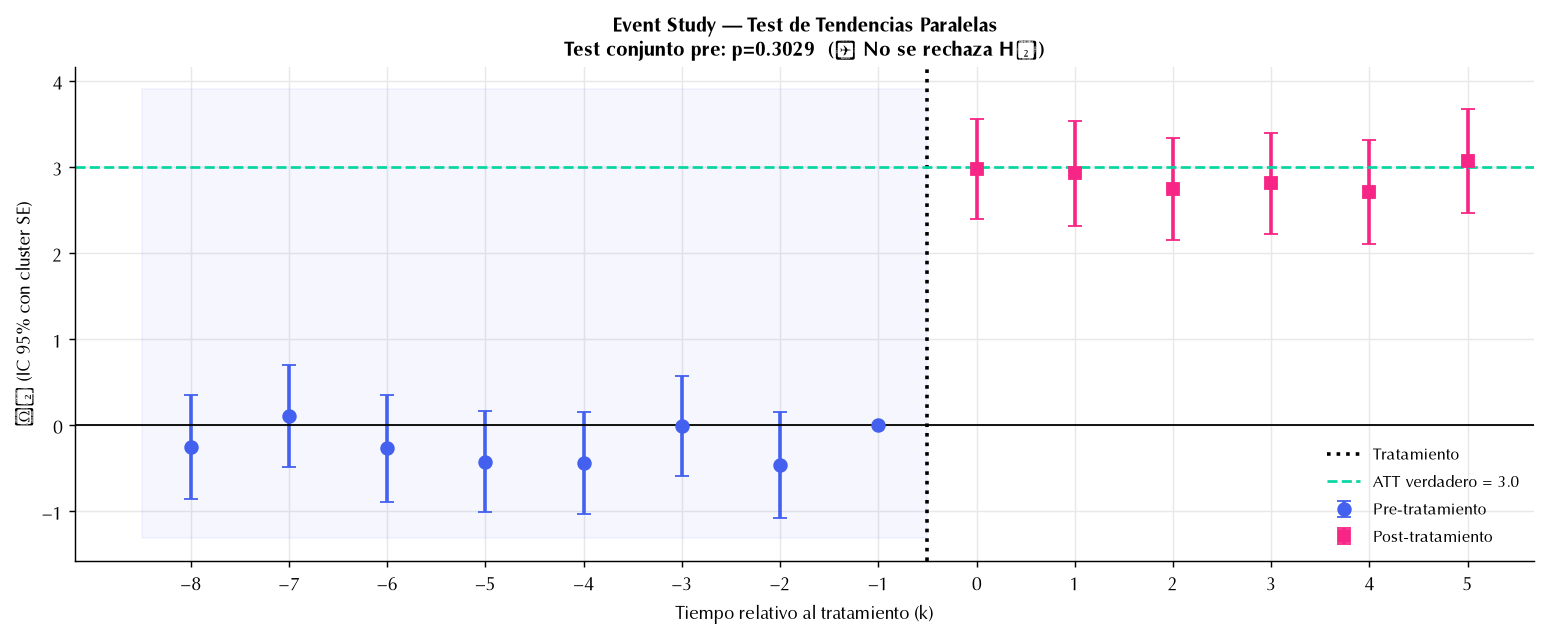

Post-tratamiento media δₖ: 2.8737
ATT verdadero:              3.0


In [10]:
# Crear dummies de evento: Treated_i × 1[k = j] para todo j ≠ -1
k_values = sorted(df['k'].unique())
k_no_ref = [k for k in k_values if k != -1]

for k in k_no_ref:
    col = f'D_{k}' if k >= 0 else f'Dm{abs(k)}'
    df[col] = ((df['k'] == k) & (df['treated'] == 1)).astype(int)

dummy_cols = [f'D_{k}' if k >= 0 else f'Dm{abs(k)}' for k in k_no_ref]

# FE de unidad y período
X_es = pd.get_dummies(df[['unit', 't_idx']], columns=['unit', 't_idx'],
                      drop_first=True, dtype=float)
X_es = pd.concat([X_es, df[dummy_cols]], axis=1)

mod_es = sm.OLS(df['Y'], sm.add_constant(X_es)).fit(
    cov_type='cluster', cov_kwds={'groups': df['unit']})

# Extraer coeficientes del event study
es_coefs = pd.DataFrame({
    'k':    k_no_ref,
    'coef': [mod_es.params.get(c, np.nan) for c in dummy_cols],
    'se':   [mod_es.bse.get(c, np.nan)    for c in dummy_cols],
})
# Agregar período de referencia k=-1
ref = pd.DataFrame({'k': [-1], 'coef': [0.0], 'se': [0.0]})
es_coefs = pd.concat([es_coefs, ref]).sort_values('k').reset_index(drop=True)
es_coefs['ci95'] = 1.96 * es_coefs['se']

# Test conjunto pre-tendencias
pre_cols  = [f'Dm{abs(k)}' for k in k_no_ref if k < 0]
R = np.zeros((len(pre_cols), len(mod_es.params)))
for row, col in enumerate(pre_cols):
    if col in mod_es.params.index:
        R[row, list(mod_es.params.index).index(col)] = 1
f_test = mod_es.f_test(R)
pre_p  = float(f_test.pvalue)

# Gráfica event study
pre_mask  = es_coefs['k'] < 0
post_mask = es_coefs['k'] >= 0

fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(es_coefs.loc[pre_mask, 'k'], es_coefs.loc[pre_mask, 'coef'],
            yerr=es_coefs.loc[pre_mask, 'ci95'],
            fmt='o', color='#4361ee', capsize=4, linewidth=2, markersize=7,
            label='Pre-tratamiento')
ax.errorbar(es_coefs.loc[post_mask, 'k'], es_coefs.loc[post_mask, 'coef'],
            yerr=es_coefs.loc[post_mask, 'ci95'],
            fmt='s', color='#f72585', capsize=4, linewidth=2, markersize=7,
            label='Post-tratamiento')

ax.axhline(0,       color='black', linewidth=1)
ax.axvline(-0.5,    color='black', linewidth=2, linestyle=':', label='Tratamiento')
ax.axhline(TRUE_ATT, color='#06d6a0', linewidth=1.5, linestyle='--',
           label=f'ATT verdadero = {TRUE_ATT}')
ax.fill_betweenx(ax.get_ylim(), -T_pre - 0.5, -0.5, alpha=0.05, color='#4361ee')

ax.set_xlabel('Tiempo relativo al tratamiento (k)')
ax.set_ylabel('δₖ (IC 95% con cluster SE)')
ax.set_title(f'Event Study — Test de Tendencias Paralelas\nTest conjunto pre: p={pre_p:.4f}  '
             f'({"✅ No se rechaza H₀" if pre_p > 0.05 else "❌ Rechaza H₀"})')
ax.set_xticks(k_values)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Post-tratamiento media δₖ: {es_coefs.loc[post_mask, "coef"].mean():.4f}')
print(f'ATT verdadero:              {TRUE_ATT}')

## Sección 3 — TWFE: estimación y errores estándar con correlación serial

### ¿Por qué el TWFE funciona?

El estimador within (FE) demea las variables restando la media de unidad y la media temporal:
$$\tilde{Y}_{it} = Y_{it} - \bar{Y}_i - \bar{Y}_t + \bar{Y}$$
$$\hat{\delta}_{TWFE} = \frac{\sum_{it} \tilde{D}_{it} \tilde{Y}_{it}}{\sum_{it} \tilde{D}_{it}^2}$$

Al demenar por unidad, eliminamos cualquier diferencia de nivel entre tratados y controles. Al demenar por período, eliminamos cualquier shock temporal común. Lo que queda es la variación *within*: cambios para la misma unidad en distintos períodos.

### El problema de la correlación serial (Bertrand, Duflo & Mullainathan, 2004)

Con datos de panel, los residuos de la misma unidad están correlacionados a lo largo del tiempo. Los SE clásicos de OLS asumen independencia → los subestiman → sobrerechazan $H_0$.

La solución: **cluster-robust SE** al nivel de la unidad de tratamiento:
$$V_{cluster} = (X'X)^{-1} \left(\sum_{i} X_i' \hat{u}_i \hat{u}_i' X_i\right) (X'X)^{-1}$$

> **BDM (2004):** Revisaron estudios de salario mínimo con datos de estado×año. Al ignorar la correlación serial, el rechazo de $H_0$ a 5% ocurría el 45% de las veces en datos simulados sin efecto.

### Cuántos clusters necesitamos

Con pocos clusters (< 50), los cluster-robust SE tienen distorsión de tamaño finito:
- **< 20 clusters** → bootstrap de wild cluster (Cameron, Gelbach & Miller, 2008)
- **< 10 clusters** → permutation tests / randomization inference
- **1 cluster** → Newey-West HAC

In [11]:
# TWFE: Y_it = α_i + λ_t + δ·(Treated × Post) + ε
X_twfe = pd.get_dummies(df[['unit', 't_idx']], columns=['unit', 't_idx'],
                        drop_first=True, dtype=float)
X_twfe['did'] = df['did_term'].values

# Diferentes tipos de SE
mod_base    = sm.OLS(df['Y'], sm.add_constant(X_twfe)).fit()
mod_robust  = sm.OLS(df['Y'], sm.add_constant(X_twfe)).fit(cov_type='HC3')
mod_cluster = sm.OLS(df['Y'], sm.add_constant(X_twfe)).fit(
    cov_type='cluster', cov_kwds={'groups': df['unit']})

print('TWFE — Comparación de Errores Estándar (Bertrand, Duflo & Mullainathan, 2004)')
print('─' * 65)
print(f'{"Especificación":<25} {"δ (ATT)":>10} {"SE":>8} {"t":>8} {"p":>8}')
print('─' * 65)
for label, mod in [
    ('SE clásicos',       mod_base),
    ('SE robustos (HC3)', mod_robust),
    ('SE cluster (unit)', mod_cluster),
]:
    d = mod.params['did']; se = mod.bse['did']
    t = d/se; p = mod.pvalues['did']
    print(f'{label:<25} {d:>10.4f} {se:>8.4f} {t:>8.2f} {p:>8.4f}')

print(f'\nATT verdadero: {TRUE_ATT}')
print()
print('SE cluster > SE clásicos → clusterizar infla correctamente la varianza')
print('al tener en cuenta la correlación serial intra-unidad.')

TWFE — Comparación de Errores Estándar (Bertrand, Duflo & Mullainathan, 2004)
─────────────────────────────────────────────────────────────────
Especificación               δ (ATT)       SE        t        p
─────────────────────────────────────────────────────────────────
SE clásicos                   3.0915   0.1077    28.70   0.0000
SE robustos (HC3)             3.0915   0.1118    27.66   0.0000
SE cluster (unit)             3.0915   0.1123    27.54   0.0000

ATT verdadero: 3.0

SE cluster > SE clásicos → clusterizar infla correctamente la varianza
al tener en cuenta la correlación serial intra-unidad.


## Sección 4 — Staggered DiD: el problema de pesos negativos

### ¿Por qué TWFE falla con staggered adoption?

Con timing heterogéneo de tratamiento, TWFE usa a las **unidades ya tratadas** como grupo de comparación para las que se tratan después. Si el efecto del tratamiento varía en el tiempo (e.g., crece), el "control" ya tratado tiene un outcome inflado → el DiD 2×2 implícito es negativo → pesos negativos en el estimador.

### Teorema de Goodman-Bacon (2021)

Sea $n_k$ el tamaño del grupo $k$ y $\bar{D}_k$ su fracción de períodos tratados. El estimador TWFE se descompone como:

$$\hat{\delta}_{TWFE} = \sum_{\{k,l\}: k\text{ antes que }l} w_{kl}^k \hat{\delta}_{kl}^k + w_{kl}^l \hat{\delta}_{kl}^l$$

donde:
- $\hat{\delta}_{kl}^k$: DiD usando a $l$ como control para $k$ (grupo tardío = control para el temprano) 
- $\hat{\delta}_{kl}^l$: DiD usando a $k$ como control para $l$ (grupo temprano = "control contaminado")
- Los pesos dependen de los tamaños de grupo y varianza de $D_{it}$ — y pueden ser negativos

**Ejemplo:** Si G4 tiene efecto 4 en t=8 y G8 tiene efecto 2, cuando estimamos el efecto de G8 usando G4 como control, el "control" ya tiene outcome inflado por el tratamiento → $\hat{\delta}_{kl}^l < 0$ y entra con peso positivo → TWFE subestima el ATT promedio.

### Solución: Callaway & Sant'Anna (2021) — ATT(g,t)

**Paso 1:** Para cada cohorte $g$ y período $t \geq g$, estimar:
$$\widehat{ATT}(g,t) = E[Y_t - Y_{g-1} \mid G=g] - E[Y_t - Y_{g-1} \mid C]$$
donde $C$ = grupo "nunca tratado" (o "no-yet-treated").

**Paso 2:** Agregar con pesos:
$$\hat{\theta} = \sum_{g} \sum_{t \geq g} \frac{n_g}{n} \cdot \frac{1}{T-g+1} \cdot \widehat{ATT}(g,t)$$

**Ventaja clave:** Nunca usa unidades tratadas como controles → sin pesos negativos → robusto a heterogeneidad de efectos.

Staggered DiD — Goodman-Bacon (2021) + Callaway & Sant'Anna (2021)
ATT promedio verdadero: 2.1667
TWFE naïve estimado:    2.2456  ← puede estar sesgado con HTE temporal

ATT por cohorte (Callaway & Sant'Anna):
Cohorte          ATT verdadero   ATT estimado       SE
───────────────────────────────────────────────────────
Cohorte G4              4.0000         3.7860   0.1511
Cohorte G8              2.0000         1.9881   0.1225
Cohorte G12             0.5000         0.4087   0.1434


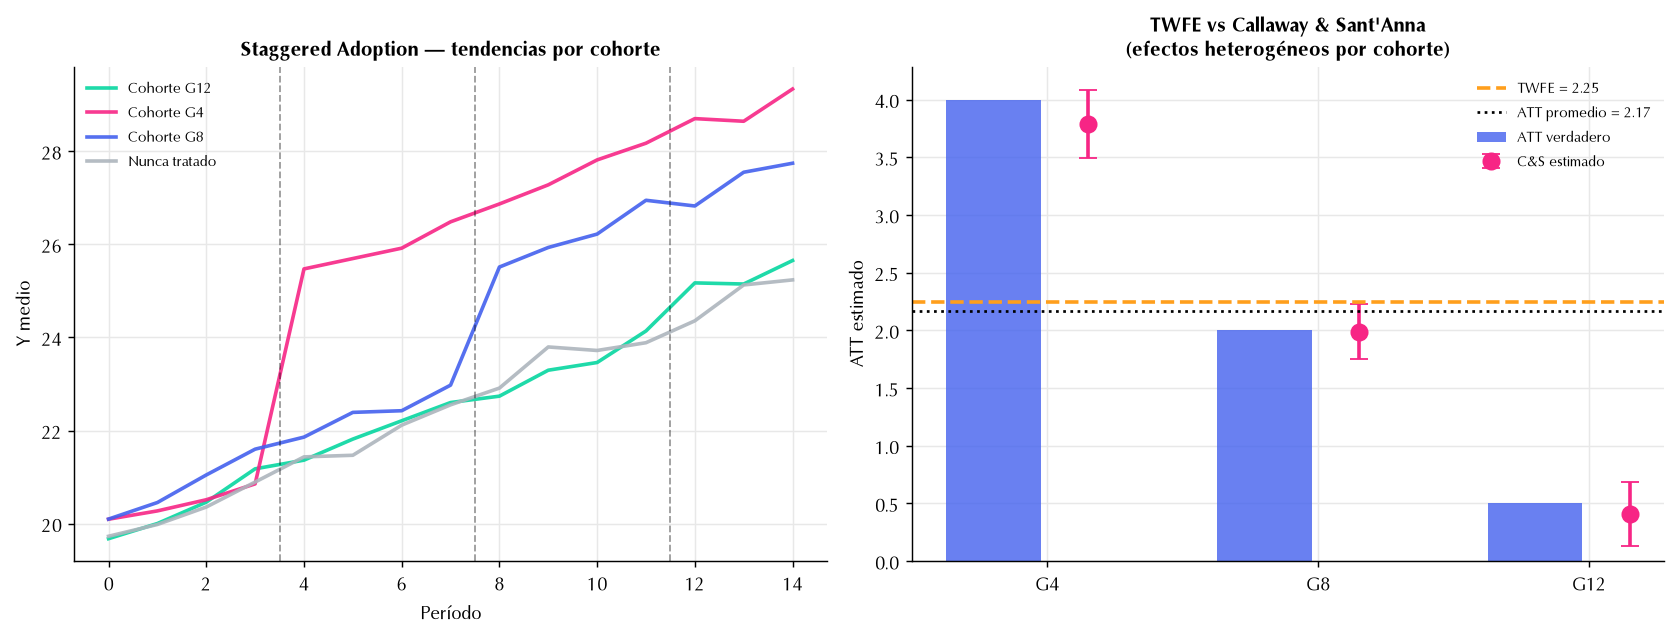

In [12]:
# Staggered: 3 cohortes tratadas en momentos distintos + grupo control
np.random.seed(42)
N_coh = 80   # unidades por cohorte
T_stag = 15

cohorts_info = {
    4:  {'ATT': 4.0, 'label': 'Cohorte G4'},
    8:  {'ATT': 2.0, 'label': 'Cohorte G8'},
    12: {'ATT': 0.5, 'label': 'Cohorte G12'},
}
ATT_true_avg = np.mean([v['ATT'] for v in cohorts_info.values()])

rows_stag = []
unit_id = 0

# Controles (nunca tratados)
afe_c = np.random.normal(20, 3, N_coh)
for i in range(N_coh):
    for t in range(T_stag):
        y = afe_c[i] + 0.4*t + np.random.normal(0, 1.5)
        rows_stag.append({'unit': unit_id+i, 'cohort': 0, 'cohort_label': 'Nunca tratado',
                          't': t, 'D': 0, 'rel_time': np.nan, 'Y': y})
unit_id += N_coh

# Cohortes tratadas
for g, info in cohorts_info.items():
    afe = np.random.normal(20, 3, N_coh)
    for i in range(N_coh):
        for t in range(T_stag):
            D   = int(t >= g)
            eff = info['ATT'] * D
            y   = afe[i] + 0.4*t + eff + np.random.normal(0, 1.5)
            rows_stag.append({'unit': unit_id+i, 'cohort': g,
                              'cohort_label': info['label'],
                              't': t, 'D': D, 'rel_time': t - g, 'Y': y})
    unit_id += N_coh

df_stag = pd.DataFrame(rows_stag)

# TWFE naïve
X_twfe_s = pd.get_dummies(df_stag[['unit', 't']], columns=['unit', 't'],
                           drop_first=True, dtype=float)
X_twfe_s['D'] = df_stag['D'].values
mod_twfe_s = sm.OLS(df_stag['Y'], sm.add_constant(X_twfe_s)).fit(
    cov_type='cluster', cov_kwds={'groups': df_stag['unit']})
twfe_est = mod_twfe_s.params['D']

# ATT(g,t): DiD por cohorte vs controles (Callaway & Sant'Anna approach)
att_by_cohort = {}
controls = df_stag[df_stag['cohort'] == 0]

for g, info in cohorts_info.items():
    cohort_df = df_stag[df_stag['cohort'] == g]
    combo = pd.concat([cohort_df, controls])
    combo['treated_unit'] = (combo['cohort'] == g).astype(int)
    combo['post'] = (combo['t'] >= g).astype(int)
    combo['did_term'] = combo['treated_unit'] * combo['post']
    X_g = pd.get_dummies(combo[['unit', 't']], columns=['unit', 't'],
                         drop_first=True, dtype=float)
    X_g['did'] = combo['did_term'].values
    mod_g = sm.OLS(combo['Y'], sm.add_constant(X_g)).fit(
        cov_type='cluster', cov_kwds={'groups': combo['unit']})
    att_by_cohort[g] = {
        'label': info['label'], 'ATT_true': info['ATT'],
        'ATT_est': mod_g.params['did'], 'ATT_se': mod_g.bse['did'],
    }

print('Staggered DiD — Goodman-Bacon (2021) + Callaway & Sant\'Anna (2021)')
print(f'ATT promedio verdadero: {ATT_true_avg:.4f}')
print(f'TWFE naïve estimado:    {twfe_est:.4f}  ← puede estar sesgado con HTE temporal')
print()
print('ATT por cohorte (Callaway & Sant\'Anna):')
print(f'{"Cohorte":<15} {"ATT verdadero":>14} {"ATT estimado":>14} {"SE":>8}')
print('─' * 55)
for g, res in att_by_cohort.items():
    print(f'{res["label"]:<15} {res["ATT_true"]:>14.4f} {res["ATT_est"]:>14.4f} {res["ATT_se"]:>8.4f}')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tendencias por cohorte
ax = axes[0]
colors_c = {'Cohorte G4': '#f72585', 'Cohorte G8': '#4361ee',
             'Cohorte G12': '#06d6a0', 'Nunca tratado': '#adb5bd'}
for label, grp in df_stag.groupby('cohort_label'):
    mn = grp.groupby('t')['Y'].mean()
    ax.plot(mn.index, mn.values, linewidth=2, color=colors_c.get(label, '#333'),
            label=label, alpha=0.9)
for g in cohorts_info:
    ax.axvline(g - 0.5, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.set_xlabel('Período'); ax.set_ylabel('Y medio')
ax.set_title('Staggered Adoption — tendencias por cohorte')
ax.legend(fontsize=8)

# Comparación TWFE vs CS
ax2 = axes[1]
g_labels = [f'G{g}' for g in att_by_cohort]
true_vals = [v['ATT_true'] for v in att_by_cohort.values()]
est_vals  = [v['ATT_est']  for v in att_by_cohort.values()]
se_vals   = [v['ATT_se']   for v in att_by_cohort.values()]

x_pos = np.arange(len(g_labels))
ax2.bar(x_pos - 0.2, true_vals, 0.35, color='#4361ee', alpha=0.8, label='ATT verdadero')
ax2.errorbar(x_pos + 0.15, est_vals, yerr=1.96*np.array(se_vals),
             fmt='o', color='#f72585', capsize=5, linewidth=2, markersize=9,
             label='C&S estimado')
ax2.axhline(twfe_est, color='#ff9f1c', linewidth=2, linestyle='--',
            label=f'TWFE = {twfe_est:.2f}')
ax2.axhline(ATT_true_avg, color='black', linewidth=1.5, linestyle=':',
            label=f'ATT promedio = {ATT_true_avg:.2f}')
ax2.set_xticks(x_pos); ax2.set_xticklabels(g_labels)
ax2.set_ylabel('ATT estimado')
ax2.set_title('TWFE vs Callaway & Sant\'Anna\n(efectos heterogéneos por cohorte)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Sección 5 — Covariables: tendencias paralelas condicionales y DiD doblemente robusto

Si las covariables predicen las **tendencias** (no solo los niveles), PT incondicional
falla y hay que trabajar bajo **CPT + SO**. La tentación habitual — "agregarle $X$ al
TWFE" — es incorrecta (Caetano & Callaway, 2024):

1. las $X$ fijas en el tiempo se eliminan con los efectos fijos (habría que interactuarlas
   con el tiempo);
2. con efectos heterogéneos, $\beta_{treat}$ es un promedio con **pesos no convexos** de los
   $ATT_X$ más términos de sesgo — puede incluso cambiar de signo;
3. covariables que responden al tratamiento son *bad controls*.

### Estimadores "forward-engineered" del ATT bajo CPT (Baker et al. 2026, §4.4)

| Estimador | Modelo requerido | Receta |
|---|---|---|
| **RA** (regression adjustment) | outcome: $\mu(x) = E[\Delta Y \mid X{=}x, D{=}0]$ | $\frac{1}{n_1}\sum_{D=1}(\Delta Y_i - \hat\mu(X_i))$ |
| **IPW** (Abadie 2005) | propensity: $p(x) = P(D{=}1 \mid x)$ | reponderar controles por $\frac{p(X)}{1-p(X)}$ |
| **DR** (Sant'Anna & Zhao 2020) | *cualquiera de los dos* | RA + corrección IPW sobre los residuos |

El **doblemente robusto** es consistente si *al menos uno* de los dos modelos de trabajo
está bien especificado — es el default recomendado por el paper y lo que implementan los
paquetes `did` (R) y `csdid`/`drdid` (Stata), con trimming de propensity scores > 0.995.
Siempre graficar la distribución del propensity score por grupo antes de confiar en
cualquiera de ellos.


In [ ]:
# ── RA vs IPW vs DR cuando solo vale PT CONDICIONAL ───────────────────────
# Dos períodos. x afecta la selección al tratamiento Y la tendencia (no lineal):
# PT incondicional falla, y los modelos lineales en x están mal especificados.
from sklearn.linear_model import LogisticRegression

def estimadores_did(n=4000, seed=0):
    rng = np.random.default_rng(seed)
    x  = rng.normal(0, 1, n)
    d  = rng.binomial(1, 1/(1 + np.exp(-0.9*x)))
    tendencia = 1.0 + 2.0*x + 1.5*x**2            # tendencia no tratada depende de x
    tau       = 2.0 + 1.0*x                        # efecto heterogéneo
    dy = tendencia + tau*d + rng.normal(0, 1, n)   # Delta Y observado
    att_true = tau[d == 1].mean()

    res = {}
    res['DiD 2x2 naive (PT incond.)'] = dy[d==1].mean() - dy[d==0].mean()
    # "agregar x a la regresion" (estilo TWFE en diferencias)
    res['OLS  dY ~ D + x'] = sm.OLS(dy, sm.add_constant(np.column_stack([d, x]))).fit().params[1]
    # RA mal especificado (lineal)
    b1 = np.polyfit(x[d==0], dy[d==0], 1)
    res['RA outcome MAL especificado'] = (dy[d==1] - np.polyval(b1, x[d==1])).mean()
    # RA bien especificado (cuadratico)
    b2 = np.polyfit(x[d==0], dy[d==0], 2)
    res['RA outcome correcto'] = (dy[d==1] - np.polyval(b2, x[d==1])).mean()
    # IPW (Abadie 2005), version Hajek, logit correcto
    e = np.clip(LogisticRegression(C=1e6).fit(x.reshape(-1,1), d)
                .predict_proba(x.reshape(-1,1))[:,1], 1e-3, 0.995)
    w0 = (e/(1-e))[d==0]
    res['IPW propensity correcto'] = dy[d==1].mean() - np.average(dy[d==0], weights=w0)
    # DR (Sant'Anna & Zhao 2020): outcome MAL + propensity correcto
    mu_lin = np.polyval(b1, x)
    res['DR (outcome mal + PS bien)'] = ((dy[d==1] - mu_lin[d==1]).mean()
                                         - np.average(dy[d==0] - mu_lin[d==0], weights=w0))
    return res, att_true

sims = [estimadores_did(seed=s) for s in range(200)]
att_true = np.mean([t for _, t in sims])
print(f'ATT verdadero = {att_true:.3f}   (promedio de {len(sims)} simulaciones)\n')
print(f'{"estimador":<32} {"media":>8} {"sesgo":>8}')
print('─' * 50)
for k in sims[0][0]:
    v = np.mean([r[k] for r, _ in sims])
    print(f'{k:<32} {v:8.3f} {v - att_true:8.3f}')
print('\nSolo los estimadores que modelan bien la tendencia condicional — o el DR')
print('con UN modelo de trabajo correcto — recuperan el ATT.')

## Sección 6 — Pre-trends con cautela y análisis de sensibilidad (honest DiD)

Tres lecciones de Roth (2022) y Rambachan & Roth (2023), sintetizadas en Baker et al.
(2026, §5.1.2):

1. **Los pre-trends no son el supuesto.** PT restringe los períodos *post*; los pre-trends
   miden los períodos "equivocados". Pre-trends planos no prueban PT.
2. **Los pre-tests tienen baja potencia**, y **condicionar el análisis en "pasar" el
   pre-test distorsiona la inferencia** (Roth 2022): las muestras que pasan son
   seleccionadas, el sesgo sobrevive y los IC subcubren.
3. **Reemplazar el "eye-test" por sensibilidad**: acotar la violación post-tratamiento en
   múltiplos $\bar M$ del mayor pre-trend observado ("relative magnitudes") y reportar el
   conjunto identificado y el **valor de quiebre** $\bar M^*$ donde la conclusión muere.
   En el ejemplo Medicaid, permitir violaciones del tamaño del mayor pre-trend infla el IC
   a $[-11.1,\ 5.1]$: los pre-trends casi no informan. Implementación: paquete `HonestDiD`.


In [ ]:
# ── Sensibilidad estilo Rambachan & Roth sobre NUESTRO event study ───────
# Cota "relative magnitudes": violacion post <= Mbar x (mayor coeficiente pre).
pre_mask  = es_coefs['k'] < -1
gamma_max = es_coefs.loc[pre_mask, 'coef'].abs().max()
fila0     = es_coefs.loc[es_coefs['k'] == 0].iloc[0]
beta0, se0 = fila0['coef'], fila0['se']

quiebre = (beta0 - 1.96*se0) / gamma_max       # Mbar donde el intervalo toca 0
Mbars = np.linspace(0, 1.3*quiebre, 61)
lo = beta0 - 1.96*se0 - Mbars*gamma_max        # intervalo robusto (conservador)
hi = beta0 + 1.96*se0 + Mbars*gamma_max

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.fill_between(Mbars, lo, hi, alpha=0.25, color='#4361ee', label='intervalo robusto para ATT(0)')
ax.axhline(0, color='k', lw=1)
ax.axvline(1.0, color='#888', ls=':', lw=1)
ax.axvline(quiebre, color='#f72585', ls='--', lw=1.5,
           label=f'valor de quiebre $\\bar{{M}}^* \\approx$ {quiebre:.2f}')
ax.set_xlabel(r'$\bar M$ = violación permitida / mayor pre-trend observado')
ax.set_ylabel('ATT en k = 0')
ax.set_title('Honest DiD (espíritu Rambachan & Roth 2023):\n¿qué tan grande debe ser la violación de PT para matar el resultado?')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Mayor coeficiente pre: {gamma_max:.3f}   ATT(0) = {beta0:.3f} (SE {se0:.3f})')
print(f'El efecto sobrevive violaciones de hasta ~{quiebre:.1f}x los pre-trends observados.')
print('(El método real usa desigualdades de momentos — paquete HonestDiD en R.)')

## Sección 7 — ¿Qué grupo de comparación? Tres supuestos PT para staggered

La elección del grupo de comparación para cada $ATT(g,t)$ **es** la elección del supuesto
de tendencias paralelas (Baker et al. 2026, §5.2):

| Supuesto | Comparación para $ATT(g,t)$ | Trade-off |
|---|---|---|
| **PT-GT-NEV** | nunca tratados | el más limpio; requiere un pool nunca-tratado creíble |
| **PT-GT-NYT** | aún no tratados en $t$ | más datos; el punto medio preferido por el paper |
| **PT-GT-ALL** | todos los períodos y grupos | máxima precisión; *impone* pre-trends paralelos |

Estimadores asociados: análogos muestrales de los bloques 2×2 (Callaway & Sant'Anna 2021,
ecs. 27–28 del paper — lo que hicimos arriba con los nunca tratados), la regresión saturada
de Sun & Abraham (2021), y bajo PT-GT-ALL el "TWFE extendido" de Wooldridge (2025), que es
numéricamente idéntico a los estimadores de **imputación** (Borusyak, Jaravel & Spiess 2024;
Gardner 2022; Liu, Wang & Xu 2024) con panel balanceado.

Sobre el TWFE estático, la descomposición mínima del paper (3 grupos, 2 períodos):
$$\beta^{twfe} = ATT(2,2) + w_1 \big[ATT(1,1) - ATT(1,2)\big]$$
— peso **negativo** sobre $ATT(1,2)$ salvo efectos estáticos. Veredicto textual:
*"we do not recommend using it"*.

Al agregar los $ATT(g,t)$ en un event study, usar pesos = participación de cada cohorte
entre los tratados observados en el event time $e$, y cuidar el **desbalance en event
time** (las cohortes tardías salen de la muestra en $e$ grandes y cambia la composición —
ec. 32 del paper).


## 8 — Checklist de validación DiD (actualizado a Baker et al. 2026)

```
✅ 1. PARÁMETRO OBJETIVO
        → ¿Qué ATT? ¿Ponderado por unidades o por población? (definen parámetros distintos)

✅ 2. SUPUESTO DE IDENTIFICACIÓN, CON NOMBRE
        → ¿PT incondicional, CPT, PT-GT-NEV, PT-GT-NYT o PT-GT-ALL?
        → No anticipación (¿el "tratamiento" empieza en el anuncio?)
        → Overlap fuerte si hay covariables

✅ 3. TENDENCIAS PARALELAS (evidencia, no prueba)
        → Event study: δₖ ≈ 0 para k < 0 — pero recordar su baja potencia (Roth 2022)
        → Sensibilidad Rambachan & Roth (2023): conjunto identificado y valor de quiebre M̄*
        → Sensibilidad a forma funcional: niveles vs logs (Roth & Sant'Anna 2023b)

✅ 4. COVARIABLES
        → Balance en niveles Y en cambios (diferencias normalizadas < 0.25)
        → Bajo CPT: RA / IPW / doblemente robusto (Sant'Anna & Zhao 2020) — no "agregar X al TWFE"
        → Covariables afectadas por el tratamiento = bad controls (Caetano & Callaway 2024)

✅ 5. NO ANTICIPACIÓN + SUTVA
        → Coeficientes en k cercanos a -1 ≈ 0; sin spillovers tratados-controles

✅ 6. ERRORES ESTÁNDAR
        → Clusterizar al nivel de asignación del tratamiento
        → Bandas de confianza SIMULTÁNEAS (sup-t) para el event study completo
        → Con < 50 clusters → wild bootstrap / permutación

✅ 7. STAGGERED ADOPTION
        → ATT(g,t) con controles limpios (nunca / aún-no tratados); agregar con pesos explícitos
        → Callaway & Sant'Anna (2021), Sun & Abraham (2021), imputación (BJS 2024 / Wooldridge 2025)
        → Evitar TWFE estático; cuidar el desbalance en event time al agregar
```

## Los 8 pasos del practicante (Baker et al. 2026, conclusión)

1. **Definir los parámetros objetivo** (bloques 2×2 y cómo se agregan)
2. **Declarar formalmente los supuestos de identificación**
3. **Elegir el método de estimación** derivado de 1 + 2 (medias, RA, IPW, DR)
4. **Discutir las fuentes de incertidumbre** (¿qué es aleatorio?, ¿dónde clusterizar?)
5. **Estimar**
6. **Análisis de sensibilidad** (honest DiD, placebos, forma funcional)
7. **Análisis de heterogeneidad** (por cohorte, event time, covariables)
8. **Seguir aprendiendo** — si los supuestos son implausibles, cambiar de diseño

## Resumen

| Componente | Herramienta | Referencia |
|---|---|---|
| Marco general | Forward engineering de bloques 2×2 | Baker et al. (2026) |
| Estimación básica | 4 medias ≡ OLS con interacción, cluster SE | Card & Krueger (1994) |
| Covariables (CPT) | DiD doblemente robusto (`did`, `DRDID`) | Sant'Anna & Zhao (2020) |
| Pre-trends | Event study + cautela por baja potencia | Roth (2022) |
| Sensibilidad | Conjunto identificado, valor de quiebre M̄* (`HonestDiD`) | Rambachan & Roth (2023) |
| Cluster SE | Agrupar por unidad de tratamiento | Bertrand, Duflo & Mullainathan (2004) |
| Staggered TWFE | Descomposición de pesos (diagnóstico) | Goodman-Bacon (2021) |
| Staggered robusto | ATT(g,t) por cohorte + agregación | Callaway & Sant'Anna (2021) |
| Staggered (regresión) | Especificación saturada por cohorte×período | Sun & Abraham (2021) |
| Staggered (imputación) | TWFE extendido ≡ imputación | Wooldridge (2025); BJS (2024) |

**Referencias:**
- Baker, A., Callaway, B., Cunningham, S., Goodman-Bacon, A. & Sant'Anna, P.H.C. (2026). Difference-in-differences designs: A practitioner's guide. *Journal of Economic Literature*, 64(2), 498–557. [psantanna.com/files/DiD_JEL.pdf]
- Roth, J., Sant'Anna, P.H.C., Bilinski, A. & Poe, J. (2023). What's trending in difference-in-differences? *Journal of Econometrics*, 235(2).
- Card, D. & Krueger, A.B. (1994). Minimum wages and employment. *American Economic Review*, 84(4).
- Bertrand, M., Duflo, E. & Mullainathan, S. (2004). How much should we trust differences-in-differences? *QJE*, 119(1).
- Sant'Anna, P.H.C. & Zhao, J. (2020). Doubly robust difference-in-differences estimators. *Journal of Econometrics*, 219(1).
- Callaway, B. & Sant'Anna, P.H.C. (2021). Difference-in-differences with multiple time periods. *Journal of Econometrics*, 225(2).
- Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing. *Journal of Econometrics*, 225(2).
- Sun, L. & Abraham, S. (2021). Estimating dynamic treatment effects in event studies. *Journal of Econometrics*, 225(2).
- Roth, J. (2022). Pretest with caution: Event-study estimates after testing for parallel trends. *AER: Insights*, 4(3).
- Rambachan, A. & Roth, J. (2023). A more credible approach to parallel trends. *Review of Economic Studies*, 90(5).
- Caetano, C. & Callaway, B. (2024). Difference-in-differences when parallel trends holds conditional on covariates. arXiv:2406.15288.
- Borusyak, K., Jaravel, X. & Spiess, J. (2024). Revisiting event study designs. *Review of Economic Studies*, 91(6).
- Wooldridge, J.M. (2025). Two-way fixed effects, the two-way Mundlak regression, and DiD estimators. *Empirical Economics*, 69(5).
- Cursos: Mixtape Sessions *Advanced DiD* (J. Roth) — github.com/Mixtape-Sessions/Advanced-DID · *Frontiers in DiD* (B. Callaway) — github.com/Mixtape-Sessions/Frontiers-in-DID
